## Parte I — 03. Feature Engineering

**Unidade Curricular:** Laboratório de Análise de Dados  
**Dataset:** NBA Stats (1947–2026) — [Kaggle](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats)  

---

### Objetivos deste Notebook

Enriquecer o dataset com novas features derivadas que os modelos de Machine Learning da Parte II vão necessitar. O objetivo é criar variáveis que capturem informação relevante mas que não existe diretamente nos dados originais:

1. Features de eficiência ofensiva — índices compostos de produção e eficiência  
2. Features de era temporal — contexto histórico e adaptação ao período de jogo  
3. Features de tier/nível de jogador — classificação relativa dentro de cada época  
4. Features físicas e demográficas — atributos corporais e longevidade  
5. Features de reconhecimento individual — historial de prémios e distinções  
6. Features de draft — contexto de entrada na liga  
7. Análise das novas features — distribuições, correlações e importância  
8. Guardar dataset enriquecido — exportar para uso na Parte II  

---
## Imports e Carregamentos

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Paths
DATA_DIR = './data/'
OUTPUT_DIR = './outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Estilo dos gráficos
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f8f8',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
})
PALETTE = ['#C9082A', '#1D428A', '#FFC72C', '#007A33', '#552583']  # Cores NBA

In [95]:
# Carregar dataset principal
df = pd.read_csv(f'{OUTPUT_DIR}dataset_nba.csv', low_memory=False)

print(f"Dataset carregado com sucesso!")
print(f"Dimensão inicial: {df.shape[0]:,} registos × {df.shape[1]} colunas")
print(f"Épocas: {df['season'].min()} a {df['season'].max()}")
print(f"Jogadores únicos: {df['player_id'].nunique():,}")
print(f"\nTargets disponíveis:")
print(f"is_allstar: {df['is_allstar'].value_counts().to_dict()}")
print(f"hof: {df['hof'].value_counts().to_dict()}")  
print(f"team_playoffs: {df['team_playoffs'].value_counts().to_dict()}")

Dataset carregado com sucesso!
Dimensão inicial: 30,987 registos × 56 colunas
Épocas: 1950 a 2026
Jogadores únicos: 4,889

Targets disponíveis:
is_allstar: {False: 29068, True: 1919}
hof: {False: 28737, True: 2250}
team_playoffs: {True: 12588, False: 9855}


In [96]:
# Carregar ficheiros auxiliares
draft_df = pd.read_csv(f'{DATA_DIR}Draft Pick History.csv', low_memory=False)
allstar_df = pd.read_csv(f'{DATA_DIR}All-Star Selections.csv', low_memory=False)
awards_df = pd.read_csv(f'{DATA_DIR}Player Award Shares.csv', low_memory=False)
eos_df = pd.read_csv(f'{DATA_DIR}End of Season Teams.csv', low_memory=False)
eos_vote_df = pd.read_csv(f'{DATA_DIR}End of Season Teams (Voting).csv', low_memory=False)

print("Ficheiros auxiliares carregados:")
print(f"  Draft History: {draft_df.shape[0]:,} registos")
print(f"  AllStar Selections: {allstar_df.shape[0]:,} registos")
print(f"  Player Award Shares: {awards_df.shape[0]:,} registos")
print(f"  End of Season Teams: {eos_df.shape[0]:,} registos")
print(f"  EOS Teams Voting: {eos_vote_df.shape[0]:,} registos")

# Registar colunas iniciais
COLUNAS_ORIGINAIS = set(df.columns)
print(f"\nDataset principal tem {len(COLUNAS_ORIGINAIS)} colunas.")

Ficheiros auxiliares carregados:
  Draft History: 8,383 registos
  AllStar Selections: 2,058 registos
  Player Award Shares: 3,465 registos
  End of Season Teams: 2,222 registos
  EOS Teams Voting: 4,484 registos

Dataset principal tem 56 colunas.


---
## Features de Eficiência Ofensiva

As estatísticas brutas (pontos, assistências, ressaltos) não capturam a eficiência que um jogador produz. Criamos aqui índices compostos que combinam produção com utilização de recursos (tempo de jogo, posse de bola, tentativas).

| Feature | Descrição |
|---|---|
| `scoring_efficiency` | Pontos por tentativa de campo ajustados pelo tempo |
| `playmaking_ratio` | Assistências vs. turnovers |
| `two_way_score` | Combinação de contribuição ofensiva e defensiva |
| `pure_scorer_index` | Capacidade de pontuar por minuto |
| `box_score_composite` | Índice composto de todas as contribuições |
| `efficiency_per_minute` | WS/48 normalizado pela utilização |
| `steal_block_ratio` | Impacto defensivo periférico |

In [97]:
# Ratio Assistências / Turnovers 
# Mede a qualidade de tomada de decisão do playmaker. Valores > 2 indicam jogadores de elite
df['ast_tov_ratio'] = np.where(
    df['tov_per_game'] > 0,
    df['ast_per_game'] / df['tov_per_game'],
    df['ast_per_game']   
).round(3)

# Eficiência de Pontuação
# True Shooting já existe, mas combinámo-la com o volume de tentativas pode destacar jogadores que são eficientes e também têm um papel ofensivo significativo.
df['scoring_efficiency'] = (
    df['ts_percent'].fillna(df['ts_percent'].median()) * df['fga_per_game']
).round(3)

# Pure Scorer Index
# Pontos por minuto de jogo
df['pure_scorer_index'] = np.where(
    df['mp_per_game'] > 0,
    (df['pts_per_game'] / df['mp_per_game']).round(3),
    np.nan
)

# Two-Way Score
# Jogadores com score alto dos dois lados são candidatos a All-NBA e All-Defense.
ows_med = df['ows'].median()
dws_med = df['dws'].median()
df['two_way_score'] = (
    df['ows'].fillna(ows_med) + df['dws'].fillna(dws_med)
).round(3)

# Box Score Composite
# Pontuação composta que captura as 5 contribuições principais numa única feature.
df['box_score_composite'] = (
     1.0 * df['pts_per_game'].fillna(0)
    + 0.7 * df['trb_per_game'].fillna(0)
    + 0.7 * df['ast_per_game'].fillna(0)
    + 1.0 * df['stl_per_game'].fillna(0)
    + 1.0 * df['blk_per_game'].fillna(0)
    - 1.0 * df['tov_per_game'].fillna(0)
).round(3)

# Steal + Block Ratio
# Capacidade de alterar o jogo adversário sem depender do tamanho
df['stl_blk_per_game'] = (
    df['stl_per_game'].fillna(0) + df['blk_per_game'].fillna(0)
).round(3)

# Rebound Dominance 
# Percentagem de ressaltos ofensivos no total de ressaltos do jogador
df['orb_share'] = np.where(
    df['trb_per_game'] > 0,
    (df['orb_per_game'].fillna(0) / df['trb_per_game']).round(3),
    np.nan
)

FEATS_SEC1 = ['ast_tov_ratio', 'scoring_efficiency', 'pure_scorer_index', 'two_way_score', 'box_score_composite', 'stl_blk_per_game', 'orb_share']

print("Features criadas:")
for f in FEATS_SEC1:
    nulos = df[f].isnull().sum()
    print(f"  {f:<30} | média={df[f].mean():.3f} | nulos={nulos}")

Features criadas:
  ast_tov_ratio                  | média=1.569 | nulos=0
  scoring_efficiency             | média=3.694 | nulos=0
  pure_scorer_index              | média=0.386 | nulos=504
  two_way_score                  | média=2.493 | nulos=0
  box_score_composite            | média=12.189 | nulos=0
  stl_blk_per_game               | média=0.934 | nulos=0
  orb_share                      | média=0.247 | nulos=563


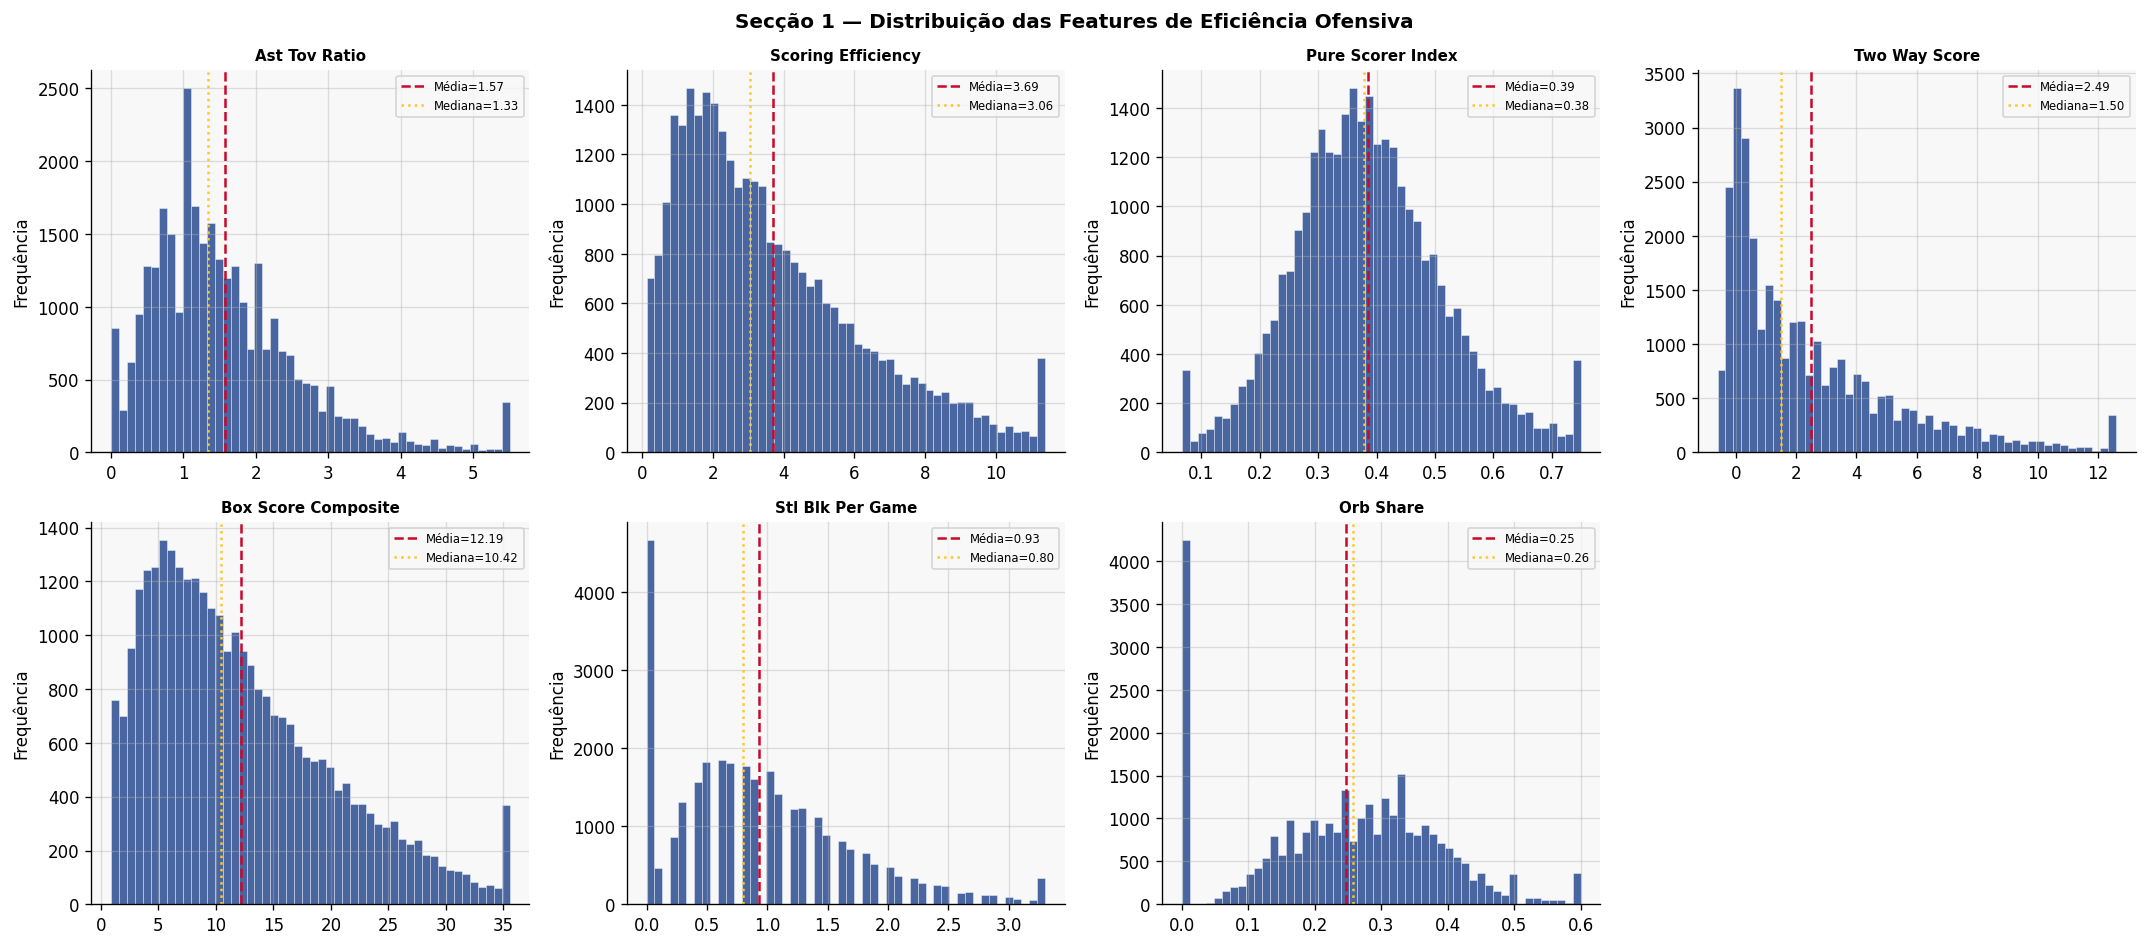

In [98]:
# Visualização da distribuição das features de eficiência
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATS_SEC1):
    data = df[feat].dropna()
    q01, q99 = data.quantile(0.01), data.quantile(0.99)
    data_clipped = data.clip(q01, q99)
    axes[i].hist(data_clipped, bins=50, color=PALETTE[1], alpha=0.8, edgecolor='white', linewidth=0.3)
    axes[i].axvline(data.mean(),   color=PALETTE[0], linestyle='--', linewidth=1.5, label=f'Média={data.mean():.2f}')
    axes[i].axvline(data.median(), color=PALETTE[2], linestyle=':',  linewidth=1.5, label=f'Mediana={data.median():.2f}')
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Frequência')

axes[-1].set_visible(False)  # esconder o último subplot vazio
plt.suptitle('Secção 1 — Distribuição das Features de Eficiência Ofensiva', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec1_eficiencia_ofensiva.png', bbox_inches='tight')
plt.show()

---
## Features de Era Temporal

O basquetebol evoluiu radicalmente ao longo de 80 anos. Um jogador com 20 pontos por jogo nos anos 60 não é comparável a um jogador com 20 pontos em 2020 — as regras, o ritmo e o estilo de jogo mudaram profundamente. Criamos aqui features que contextualizam as estatísticas dentro da era em que foram produzidas.

| Feature | Descrição |
|---|---|
| `era` | Período de jogo (pré-3pt, era clássica, era moderna, era analytics) |
| `pts_vs_era_avg` | Pontos do jogador vs. média da época |
| `pts_era_zscore` | Z-score dos pontos normalizado pela época |
| `per_era_zscore` | Z-score do PER normalizado pela época |
| `ws_era_zscore` | Z-score dos Win Shares normalizado pela época |
| `pace_era` | Proxy do ritmo de jogo da era |

In [99]:
# Classificação de Era Temporal
# Divisão da história da NBA em 5 grandes eras estruturais
def classificar_era(season):
    if season <= 1954: return 'Pre-Shot Clock'
    elif season <= 1979: return 'Classic'
    elif season <= 1999: return 'Pre-Modern'
    elif season <= 2014: return 'Analytics'
    else: return 'Modern'

df['era'] = df['season'].apply(classificar_era)

print("Distribuição de registos por Era:")
print(df['era'].value_counts().sort_index())

Distribuição de registos por Era:
era
Analytics         8374
Classic           4796
Modern            8175
Pre-Modern        8708
Pre-Shot Clock     934
Name: count, dtype: int64


In [100]:
# Z-Scores por Época
# Normalizar estatísticas Z-Score dentro de cada época para comparar eras diferentes

mask = df['g'] >= 20 # Filtro: Apenas considerar jogadores com pelo menos 20 jogos na época
calc_zscore = lambda x: (x - x.mean()) / x.std()

df.loc[mask, 'pts_era_zscore'] = df[mask].groupby('season')['pts_per_game'].transform(calc_zscore).round(3)
df.loc[mask, 'per_era_zscore'] = df[mask].groupby('season')['per'].transform(calc_zscore).round(3)
df.loc[mask, 'ws_era_zscore']  = df[mask].groupby('season')['ws'].transform(calc_zscore).round(3)
df.loc[mask, 'bpm_era_zscore'] = df[mask].groupby('season')['bpm'].transform(calc_zscore).round(3)


# Pontos vs. Média da Época 
era_avg_pts = df.groupby('season')['pts_per_game'].transform('mean')
df['pts_vs_era_avg'] = (df['pts_per_game'] - era_avg_pts).round(3)


# 2Frequência de Triplos
df['x3p_ar_era'] = (df['x3pa_per_game'].fillna(0) / (df['fga_per_game'] + 1e-9)).round(3)

FEATS_SEC2 = ['era', 'pts_era_zscore', 'per_era_zscore', 'ws_era_zscore', 'bpm_era_zscore', 'pts_vs_era_avg', 'x3p_ar_era']
print("Features criadas e normalizadas.")

Features criadas e normalizadas.


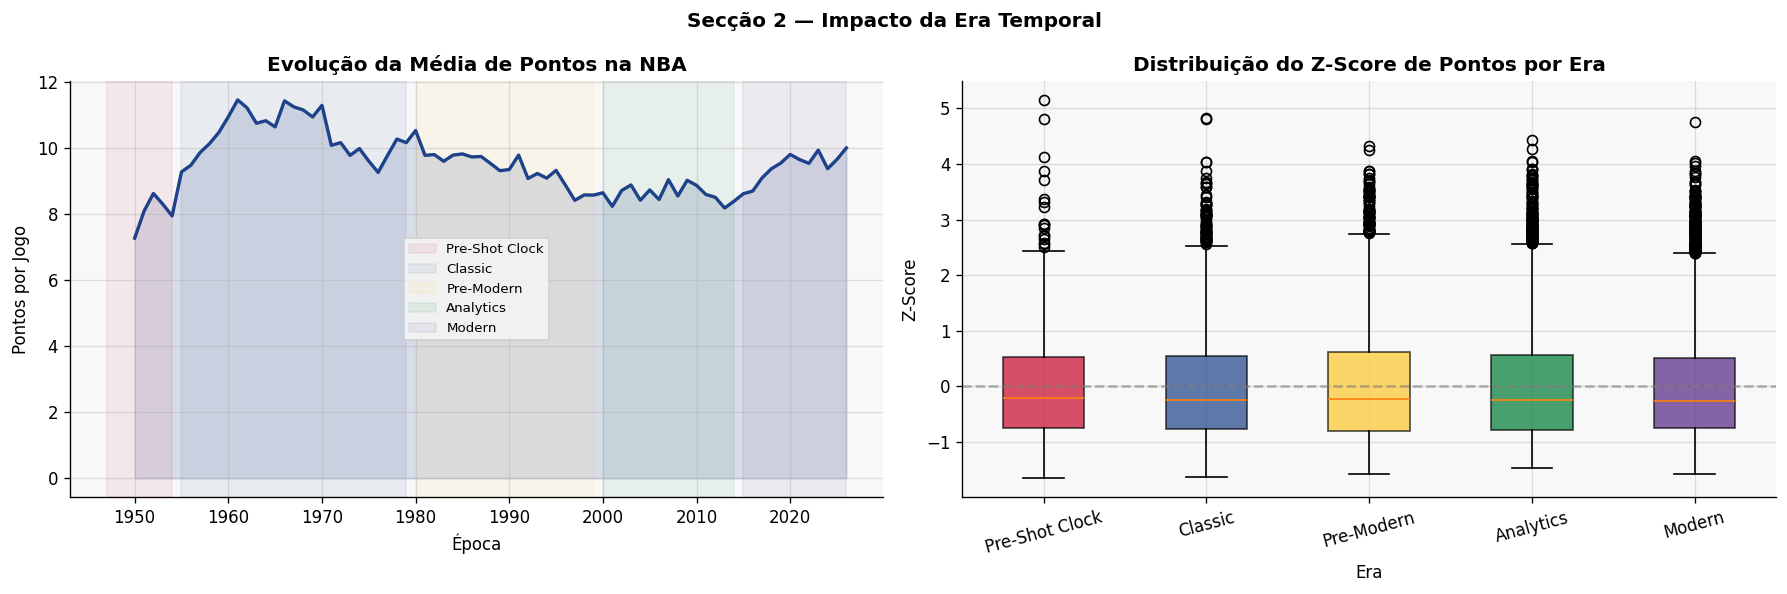

In [101]:
# Visualização da evolução dos Pontos e Z-Scores por Era
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico de média de pontos por época
pts_season = df[df['g'] >= 20].groupby('season')['pts_per_game'].mean()
axes[0].plot(pts_season.index, pts_season.values, color=PALETTE[1], linewidth=2)
axes[0].fill_between(pts_season.index, pts_season.values, alpha=0.15, color=PALETTE[1])

era_bounds = [
    (1947, 1954, 'Pre-Shot Clock', PALETTE[0]),
    (1955, 1979, 'Classic', PALETTE[1]),
    (1980, 1999, 'Pre-Modern', PALETTE[2]),
    (2000, 2014, 'Analytics', PALETTE[3]),
    (2015, 2026, 'Modern', PALETTE[4]),
]
for start, end, label, color in era_bounds:
    axes[0].axvspan(start, end, alpha=0.07, color=color, label=label)

axes[0].set_title('Evolução da Média de Pontos na NBA', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pontos por Jogo')
axes[0].legend(fontsize=8)

# Boxplot: Z-score de pontos por era
era_order = ['Pre-Shot Clock', 'Classic', 'Pre-Modern', 'Analytics', 'Modern']
era_data  = [df[df['era'] == e]['pts_era_zscore'].dropna() for e in era_order]

bp = axes[1].boxplot(era_data, labels=era_order, patch_artist=True)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title('Distribuição do Z-Score de Pontos por Era', fontweight='bold')
axes[1].set_xlabel('Era')
axes[1].set_ylabel('Z-Score')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Secção 2 — Impacto da Era Temporal', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec2_era_temporal.png', bbox_inches='tight')
plt.show()

---
## Features de Tier/Nível de Jogador

Para classificar o impacto relativo de cada jogador, criamos features que posicionam o jogador dentro da hierarquia da sua época. Um jogador de tier alto é candidato natural ao All-Star, MVP e eventualmente ao Hall of Fame.

| Feature | Descrição |
|---|---|
| `player_tier` | Classificação em 5 níveis: Star, Starter, Rotation, Bench, Fringe |
| `season_percentile_pts` | Percentil de pontos na sua época |
| `season_percentile_ws` | Percentil de win shares na sua época |
| `season_percentile_bpm` | Percentil de BPM na sua época |
| `is_top10_scorer` | Se estava no top 10 de pontuadores da sua época |
| `career_peak_ws` | Win Shares máximos numa só época (peak da carreira) |

In [102]:
# Percentis por Época
# Calcular a posição relativa de cada jogadorface aos colegas da mesma época.
mask = df['g'] >= 20

calc_percentil = lambda x: (x.rank(pct=True) * 100).round(1)

# Aplicar o cálculo agrupando por época
df.loc[mask, 'season_pct_pts'] = df[mask].groupby('season')['pts_per_game'].transform(calc_percentil)
df.loc[mask, 'season_pct_ws']  = df[mask].groupby('season')['ws'].transform(calc_percentil)
df.loc[mask, 'season_pct_bpm'] = df[mask].groupby('season')['bpm'].transform(calc_percentil)
df.loc[mask, 'season_pct_per'] = df[mask].groupby('season')['per'].transform(calc_percentil)

print("Percentis sazonais calculados")
print(f"season_pct_pts : {df['season_pct_pts'].describe().round(2).to_dict()}")

Percentis sazonais calculados
season_pct_pts : {'count': 26465.0, 'mean': 50.15, 'std': 28.87, 'min': 0.2, '25%': 25.1, '50%': 50.1, '75%': 75.2, 'max': 100.0}


In [103]:
# Player Tier
# Classificação do jogador baseada numa média ponderada de pontos, win shares e box plus-minus.
df['tier_score'] = ( df['season_pct_pts'].fillna(50) * 0.4 + df['season_pct_ws'].fillna(50)  * 0.35 + df['season_pct_bpm'].fillna(50) * 0.25).round(1)

def assign_tier(score):
    if pd.isna(score): 
        return 'Unknown'
    if score >= 90: 
        return 'Star'
    elif score >= 75: 
        return 'Starter'
    elif score >= 55: 
        return 'Rotation'
    elif score >= 35: 
        return 'Bench'
    else: 
        return 'Fringe'

df['player_tier'] = df['tier_score'].apply(assign_tier)

print("Distribuição de Tiers:")
print(df['player_tier'].value_counts())

print("\nValidação - Tiers dos All-Stars:")
print(df[df['is_allstar'] == True]['player_tier'].value_counts())

Distribuição de Tiers:
player_tier
Bench       10848
Fringe       8551
Rotation     6053
Starter      3817
Star         1718
Name: count, dtype: int64

Validação - Tiers dos All-Stars:
player_tier
Star        1039
Starter      681
Rotation     174
Bench         24
Fringe         1
Name: count, dtype: int64


In [104]:
# Top 10 Scorer da época
rank_pts = df[df['g'] >= 20].groupby('season')['pts_per_game'].rank(ascending=False)
df.loc[rank_pts.index, 'is_top10_scorer'] = (rank_pts <= 10).astype(int)
df['is_top10_scorer'] = df['is_top10_scorer'].fillna(0).astype(int)

# Top 10 Win Shares da época
rank_ws = df[df['g'] >= 20].groupby('season')['ws'].rank(ascending=False)
df.loc[rank_ws.index, 'is_top10_ws'] = (rank_ws <= 10).astype(int)
df['is_top10_ws'] = df['is_top10_ws'].fillna(0).astype(int)

# Melhor ano da carreira 
df['career_peak_ws'] = df.groupby('player_id')['ws'].transform('max').round(3)

# Épocas como All-Star Acumuladas
allstar_cumulado = ( df.sort_values('season').groupby('player_id')['is_allstar'].expanding().sum().reset_index(level=0, drop=True))
df['career_allstar_count'] = (allstar_cumulado - df['is_allstar']).clip(lower=0).astype(int)

FEATS_SEC3 = ['season_pct_pts', 'season_pct_ws', 'season_pct_bpm', 'season_pct_per',
              'tier_score', 'player_tier', 'is_top10_scorer', 'is_top10_ws',
              'career_peak_ws', 'career_allstar_count']

print("Features criadas.")

Features criadas.


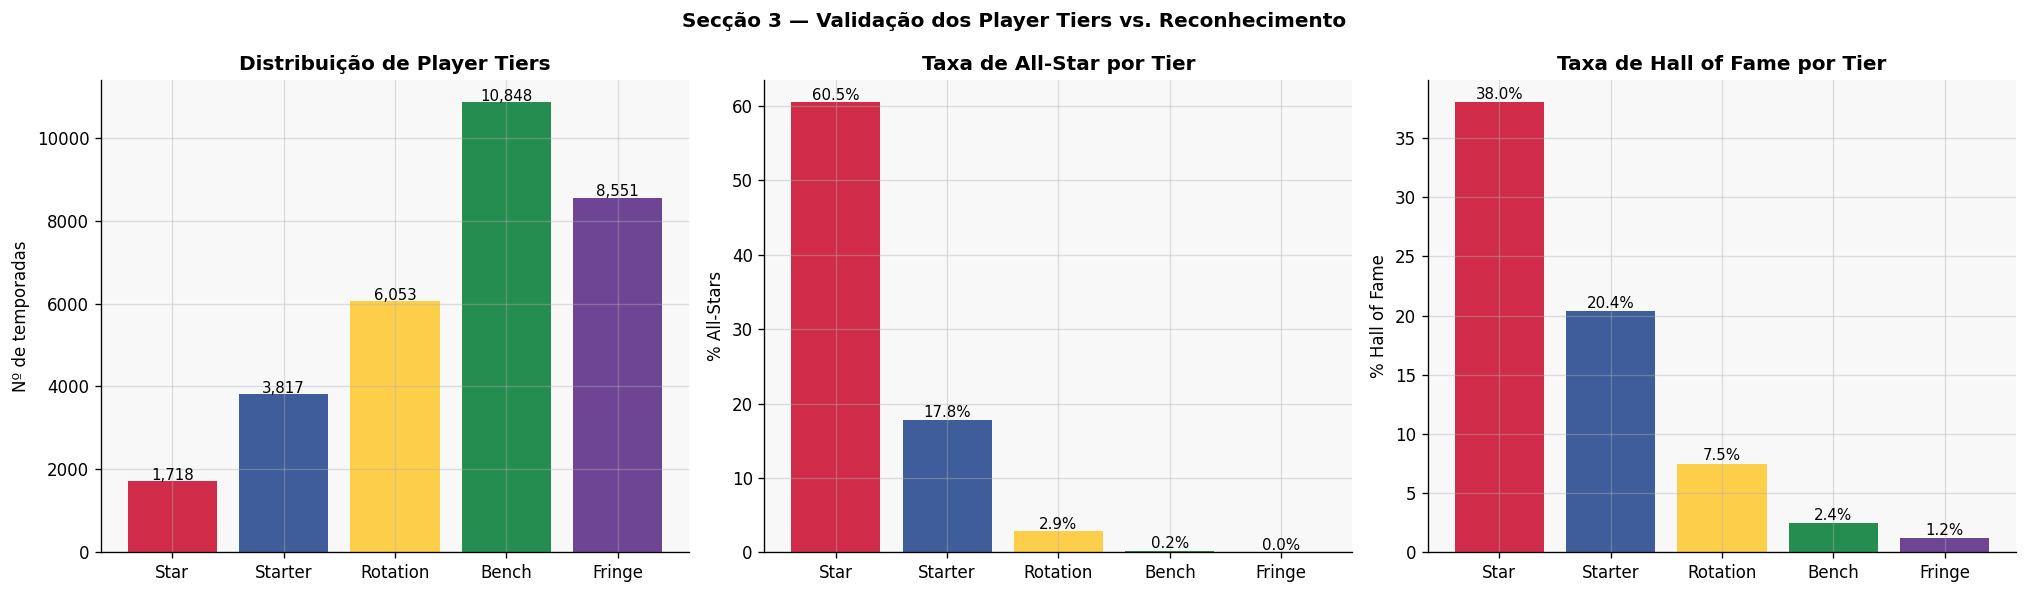

In [105]:
# Validação dos Player Tiers vs. Reconhecimento 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

tier_order = ['Star', 'Starter', 'Rotation', 'Bench', 'Fringe']
tier_colors = {t: c for t, c in zip(tier_order, PALETTE)}
cores = [tier_colors[t] for t in tier_order]

# Gráfico 1 — Distribuição de Tiers
counts = df['player_tier'].value_counts().reindex(tier_order, fill_value=0)
bars = axes[0].bar(tier_order, counts.values, color=cores, alpha=0.85)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30, f'{val:,}', ha='center', fontsize=9)
axes[0].set_title('Distribuição de Player Tiers', fontweight='bold')
axes[0].set_ylabel('Nº de temporadas')

# Gráfico 2 — % de All-Stars por Tier
allstar_rate = df.groupby('player_tier')['is_allstar'].mean().reindex(tier_order, fill_value=0) * 100
bars2 = axes[1].bar(tier_order, allstar_rate.values, color=cores, alpha=0.85)
for bar, val in zip(bars2, allstar_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
axes[1].set_title('Taxa de All-Star por Tier', fontweight='bold')
axes[1].set_ylabel('% All-Stars')

# Gráfico 3 — % de HoF por Tier (Hall of Fame)
hof_rate = df.groupby('player_tier')['hof'].mean().reindex(tier_order, fill_value=0) * 100
bars3 = axes[2].bar(tier_order, hof_rate.values, color=cores, alpha=0.85)
for bar, val in zip(bars3, hof_rate.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.1f}%', ha='center', fontsize=9)
axes[2].set_title('Taxa de Hall of Fame por Tier', fontweight='bold')
axes[2].set_ylabel('% Hall of Fame')

plt.suptitle('Secção 3 — Validação dos Player Tiers vs. Reconhecimento', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec3_player_tiers.png', bbox_inches='tight')
plt.show()

---
## Features Físicas e Demográficas

As características físicas e demográficas de um jogador têm impacto direto na sua longevidade, posição e tipo de contribuição. Criamos aqui features derivadas dos atributos físicos e da trajetória de carreira.

| Feature | Descrição |
|---|---|
| `bmi` | Índice de Massa Corporal (proxy de tipo físico) |
| `height_category` | Classificação de altura (low/mid/high guard, wing, big) |
| `career_length` | Duração total da carreira em épocas |
| `age_at_peak` | Idade no melhor ano da carreira |
| `is_veteran` | Se tem mais de 10 anos de experiência |
| `age_zscore` | Z-score da idade dentro da época (jovem/veterano relativo) |

In [106]:
# Features Físicas
df['bmi'] = np.where(
    (df['height_cm'] > 0) & (df['weight_kg'] > 0),
    (df['weight_kg'] / (df['height_cm'] / 100) ** 2).round(2),
    np.nan
)

def height_category(h):
    if pd.isna(h): return 'Unknown'
    if h < 183:    return 'Point Guard Size'
    elif h < 193:  return 'Guard/Wing'
    elif h < 203:  return 'Wing/Forward'
    elif h < 210:  return 'Power Forward'
    else:          return 'Center'

df['height_category'] = df['height_cm'].apply(height_category)

# Features de Experiência e Idade
df['career_length'] = (df['to'] - df['from'] + 1).clip(lower=1) # Duração de Carreira
df['is_veteran'] = (df['experience'] >= 10).astype(int)  # Jogadores com 10 ou mais anos de carreira
df['is_rookie'] = (df['experience'] <= 1).astype(int)  # Rookies

# Z-Score da Idade por Época 
age_mean = df.groupby('season')['age'].transform('mean')
age_std  = df.groupby('season')['age'].transform('std')
df['age_zscore'] = ((df['age'] - age_mean) / age_std).round(3)

df['is_prime_age'] = df['age'].between(22, 28).astype(int)
df['seasons_played_so_far'] = df.groupby('player_id').cumcount() + 1

FEATS_SEC4 = ['bmi', 'height_category', 'career_length', 'is_veteran', 'is_rookie', 'age_zscore', 'is_prime_age', 'seasons_played_so_far']

print("Features criadas.")

Features criadas.


---
## Features Físicas e Demográficas

As características físicas e demográficas de um jogador têm impacto direto na sua longevidade, posição e tipo de contribuição. Criamos aqui features derivadas dos atributos físicos e da trajetória de carreira.

| Feature | Descrição |
|---|---|
| `bmi` | Índice de Massa Corporal (proxy de tipo físico) |
| `height_category` | Classificação de altura (low/mid/high guard, wing, big) |
| `career_length` | Duração total da carreira em épocas |
| `age_at_peak` | Idade no melhor ano da carreira |
| `is_veteran` | Se tem mais de 10 anos de experiência |
| `age_zscore` | Z-score da idade dentro da época (jovem/veterano relativo) |

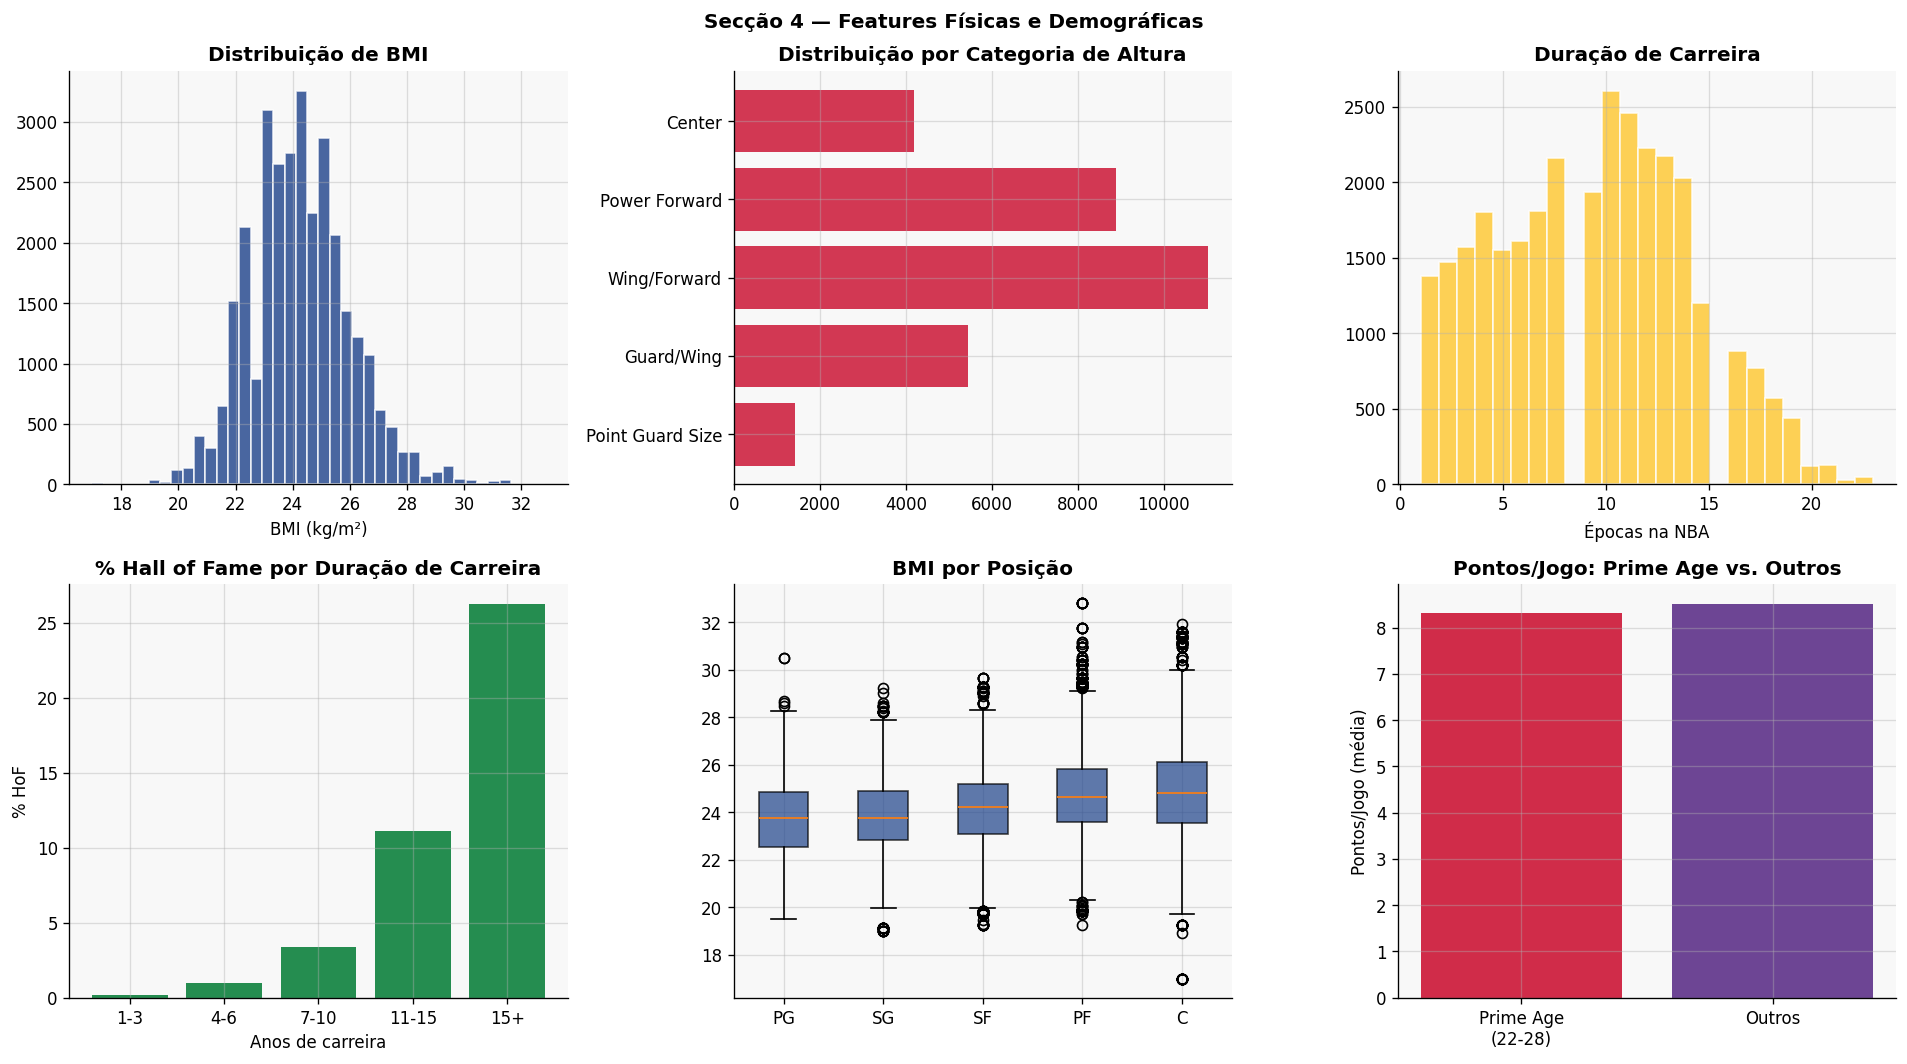

In [107]:
# Visualização das features físicas
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# BMI
axes[0,0].hist(df['bmi'].dropna(), bins=40, color=PALETTE[1], alpha=0.8, edgecolor='white')
axes[0,0].set_title('Distribuição de BMI', fontweight='bold')
axes[0,0].set_xlabel('BMI (kg/m²)')

# Altura por categoria
hcat_order = ['Point Guard Size', 'Guard/Wing', 'Wing/Forward', 'Power Forward', 'Center']
hcat_counts = df['height_category'].value_counts().reindex(hcat_order, fill_value=0)
axes[0,1].barh(hcat_order, hcat_counts.values, color=PALETTE[0], alpha=0.8)
axes[0,1].set_title('Distribuição por Categoria de Altura', fontweight='bold')

# Duração de carreira
axes[0,2].hist(df['career_length'].dropna(), bins=25, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[0,2].set_title('Duração de Carreira', fontweight='bold')
axes[0,2].set_xlabel('Épocas na NBA')

# Taxa de HoF por duração de carreira 
df['career_bin'] = pd.cut(df['career_length'], bins=[0,3,6,10,15,30], labels=['1-3','4-6','7-10','11-15','15+'])
hof_by_career = df.groupby('career_bin', observed=True)['hof'].mean() * 100
axes[1,0].bar(hof_by_career.index.astype(str), hof_by_career.values, color=PALETTE[3], alpha=0.85)
axes[1,0].set_title('% Hall of Fame por Duração de Carreira', fontweight='bold')
axes[1,0].set_xlabel('Anos de carreira')
axes[1,0].set_ylabel('% HoF')

# BMI por posição
pos_clean = df[df['pos'].isin(['PG','SG','SF','PF','C'])]
bmi_by_pos = [pos_clean[pos_clean['pos'] == p]['bmi'].dropna() for p in ['PG','SG','SF','PF','C']]
axes[1,1].boxplot(bmi_by_pos, labels=['PG','SG','SF','PF','C'], patch_artist=True, boxprops=dict(facecolor=PALETTE[1], alpha=0.7))
axes[1,1].set_title('BMI por Posição', fontweight='bold')

# Pontos por faixa etária 
prime_pts = df[df['is_prime_age'] == 1]['pts_per_game'].mean()
other_pts = df[df['is_prime_age'] == 0]['pts_per_game'].mean()
axes[1,2].bar(['Prime Age\n(22-28)', 'Outros'], [prime_pts, other_pts], color=[PALETTE[0], PALETTE[4]], alpha=0.85)
axes[1,2].set_title('Pontos/Jogo: Prime Age vs. Outros', fontweight='bold')
axes[1,2].set_ylabel('Pontos/Jogo (média)')

plt.suptitle('Secção 4 — Features Físicas e Demográficas', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec4_fisico_demografico.png', bbox_inches='tight')
plt.show()

---
## Features de Reconhecimento Individual

O historial de prémios e seleções de um jogador é um dos preditores mais fortes para All-Star e Hall of Fame. Derivamos aqui features a partir dos ficheiros de prémios, votações e seleções de fim de época.

| Feature | Descrição |
|---|---|
| `career_allnba_count` | Nº de seleções All-NBA acumuladas até esta época |
| `career_alldefense_count` | Nº de seleções All-Defense acumuladas |
| `ever_allnba_1st` | Se alguma vez foi 1ª equipa All-NBA |
| `best_mvp_share` | Maior share de votos MVP numa época |
| `career_mvp_votes` | Share acumulado de votos MVP |
| `best_allnba_share` | Melhor share de votação All-NBA numa época |
| `has_dpoy_vote` | Se alguma vez recebeu votos para DPOY |

In [108]:
# All-NBA e All-Defense acumulados
# Filtrar só NBA e criar flags por época
allnba_df = eos_df[(eos_df['type'] == 'All-NBA') & (eos_df['lg'] == 'NBA')].copy()
alldef_df = eos_df[(eos_df['type'] == 'All-Defense') & (eos_df['lg'] == 'NBA')].copy()
allnba1_df = allnba_df[allnba_df['number_tm'] == '1st'].copy() 

# Merge com o dataset principal por player_id + season
allnba_seasons = set(zip(allnba_df['player_id'], allnba_df['season']))
alldef_seasons = set(zip(alldef_df['player_id'], alldef_df['season']))
allnba1_seasons = set(zip(allnba1_df['player_id'], allnba1_df['season']))

df['is_allnba_this_season'] = df.apply(lambda r: int((r['player_id'], r['season']) in allnba_seasons), axis=1)
df['is_alldef_this_season'] = df.apply(lambda r: int((r['player_id'], r['season']) in alldef_seasons), axis=1)
df['is_allnba1_this_season'] = df.apply(lambda r: int((r['player_id'], r['season']) in allnba1_seasons), axis=1)

# Contagem acumulada excluindo a época atual para evitar data leakage
def cumulative_count_excl_current(flag_col):
    return (
        df.sort_values('season')
          .groupby('player_id')[flag_col]
          .expanding().sum()
          .reset_index(level=0, drop=True)
        - df[flag_col]
    ).clip(lower=0).astype(int)

df['career_allnba_count'] = cumulative_count_excl_current('is_allnba_this_season')
df['career_alldef_count'] = cumulative_count_excl_current('is_alldef_this_season')
df['career_allnba1_count'] = cumulative_count_excl_current('is_allnba1_this_season')

# Ever All-NBA 1st Team
ever_allnba1 = df.groupby('player_id')['is_allnba1_this_season'].transform('max')
df['ever_allnba_1st'] = ever_allnba1.astype(int)

print("Features criadas.")
print(f"All-NBA seleções totais: {df['is_allnba_this_season'].sum()}")
print(f"All-Defense seleções: {df['is_alldef_this_season'].sum()}")
print(f"All-NBA 1st Team: {df['is_allnba1_this_season'].sum()}")

Features criadas.
All-NBA seleções totais: 964
All-Defense seleções: 594
All-NBA 1st Team: 381


In [109]:
# DEBUG — verificar mismatch de player_id
allstar_ref = pd.read_csv('./data/All-Star Selections.csv')

print("=== All-Star Selections ===")
print("player_id dtype:", allstar_ref['player_id'].dtype)
print("season dtype:", allstar_ref['season'].dtype)
print("Exemplo player_ids:", allstar_ref['player_id'].head(5).tolist())
print("Exemplo seasons:", allstar_ref['season'].head(5).tolist())

print("\n=== Dataset principal ===")
print("player_id dtype:", df['player_id'].dtype)
print("season dtype:", df['season'].dtype)
print("Exemplo player_ids:", df['player_id'].head(5).tolist())
print("Exemplo seasons:", df['season'].head(5).tolist())

# Verificar se há overlap
as_ids = set(allstar_ref['player_id'].astype(str).str.strip())
df_ids = set(df['player_id'].astype(str).str.strip())
print(f"\nIDs em common: {len(as_ids & df_ids)}")
print(f"Exemplo IDs do allstar_ref: {list(as_ids)[:5]}")
print(f"Exemplo IDs do df: {list(df_ids)[:5]}")

=== All-Star Selections ===
player_id dtype: object
season dtype: int64
Exemplo player_ids: ['barnesc01', 'bookede01', 'cunnica01', 'durenja01', 'edwaran01']
Exemplo seasons: [2026, 2026, 2026, 2026, 2026]

=== Dataset principal ===
player_id dtype: object
season dtype: int64
Exemplo player_ids: ['cervial01', 'guokaal01', 'guokaal01', 'guokaal01', 'miksial01']
Exemplo seasons: [1950, 1950, 1950, 1950, 1950]

IDs em common: 508
Exemplo IDs do allstar_ref: ['natersw01', 'anderke01', 'jonesbo01', 'lewisfr02', 'schaufr01']
Exemplo IDs do df: ['griffta01', 'anderke01', 'marshve01', 'blounma01', 'rainsed01']


In [110]:
# Features de Votação de Prémios

# 1. SEGURANÇA: Garantir que is_allstar está correta (evita os NaNs do Notebook 4)
# Vamos reconstruir a coluna com base no ficheiro original para ser infalível
allstar_ref = pd.read_csv('./data/All-Star Selections.csv')
allstar_ref['player_id'] = allstar_ref['player_id'].astype(str).str.strip()
allstar_ref['season']    = allstar_ref['season'].astype(str).str.strip()
df['player_id']          = df['player_id'].astype(str).str.strip()
df['season_str']         = df['season'].astype(str).str.strip()

as_keys = set(allstar_ref['player_id'] + "_" + allstar_ref['season'])
df['is_allstar'] = (df['player_id'] + "_" + df['season_str']).isin(as_keys).astype(int)
df.drop(columns=['season_str'], inplace=True)

# MVP share por jogador e época
mvp_df = awards_df[awards_df['award'] == 'nba mvp'][['player_id', 'season', 'share', 'winner']].copy()
mvp_df = mvp_df.rename(columns={'share': 'mvp_share_season', 'winner': 'mvp_winner'})

# Limpeza vital: remover duplicados no mvp_df (caso o jogador tenha mudado de equipa)
mvp_df = mvp_df.drop_duplicates(subset=['player_id', 'season'])

# Remover colunas se já existirem (evita conflito em re-runs)
df.drop(columns=['mvp_share_season', 'mvp_winner', 'best_mvp_share', 'career_mvp_cumul'], 
        errors='ignore', inplace=True)

df = df.merge(mvp_df, on=['player_id', 'season'], how='left')
df['mvp_share_season'] = df['mvp_share_season'].fillna(0)
df['mvp_winner'] = df['mvp_winner'].fillna(False).astype(int)

# Melhor share MVP e acumulado 
df['best_mvp_share'] = df.groupby('player_id')['mvp_share_season'].transform('max')
df['career_mvp_share_cumul'] = (
    df.sort_values('season')
      .groupby('player_id')['mvp_share_season']
      .expanding().sum()
      .reset_index(level=0, drop=True)
    - df['mvp_share_season']
).clip(lower=0).round(3)

# DPOY votes 
dpoy_df = awards_df[awards_df['award'] == 'nba dpoy'][['player_id', 'season', 'share']].copy()
dpoy_set = set(dpoy_df['player_id'].unique())
df['has_dpoy_vote'] = df['player_id'].isin(dpoy_set).astype(int)

# ROY win
roy_df = awards_df[(awards_df['award'] == 'nba roy') & (awards_df['winner'] == True)]
roy_set = set(zip(roy_df['player_id'], roy_df['season']))
df['won_roy'] = df.apply(lambda r: int((r['player_id'], r['season']) in roy_set), axis=1)

print("Features de votação de prémios criadas.")
print(f"Check All-Stars: {df['is_allstar'].sum()} encontrados.") # Verificação de segurança
print(f"Jogadores com votos MVP: {(df['mvp_share_season'] > 0).sum()}")

Features de votação de prémios criadas.
Check All-Stars: 1919 encontrados.
Jogadores com votos MVP: 1081


In [111]:
# All-NBA Share de Votação
allnba_vote = eos_vote_df[(eos_vote_df['type'] == 'All-NBA') & (eos_vote_df['lg'] == 'NBA')][['player_id', 'season', 'share']]
allnba_vote = allnba_vote.rename(columns={'share': 'allnba_share_season'})
allnba_vote = allnba_vote.groupby(['player_id', 'season'])['allnba_share_season'].max().reset_index()

df = df.merge(allnba_vote, on=['player_id', 'season'], how='left')
df['allnba_share_season'] = df['allnba_share_season'].fillna(0)
df['best_allnba_share']   = df.groupby('player_id')['allnba_share_season'].transform('max')

# Na Célula 3, altera apenas esta lista:
FEATS_SEC5 = ['is_allstar', 'is_allnba_this_season', 'is_alldef_this_season', 'is_allnba1_this_season',
              'career_allnba_count', 'career_alldef_count', 'career_allnba1_count',
              'ever_allnba_1st', 'mvp_share_season', 'best_mvp_share',
              'career_mvp_share_cumul', 'has_dpoy_vote', 'won_roy',
              'allnba_share_season', 'best_allnba_share']

print("Features criadas com sucesso (via Merges).")

Features criadas com sucesso (via Merges).


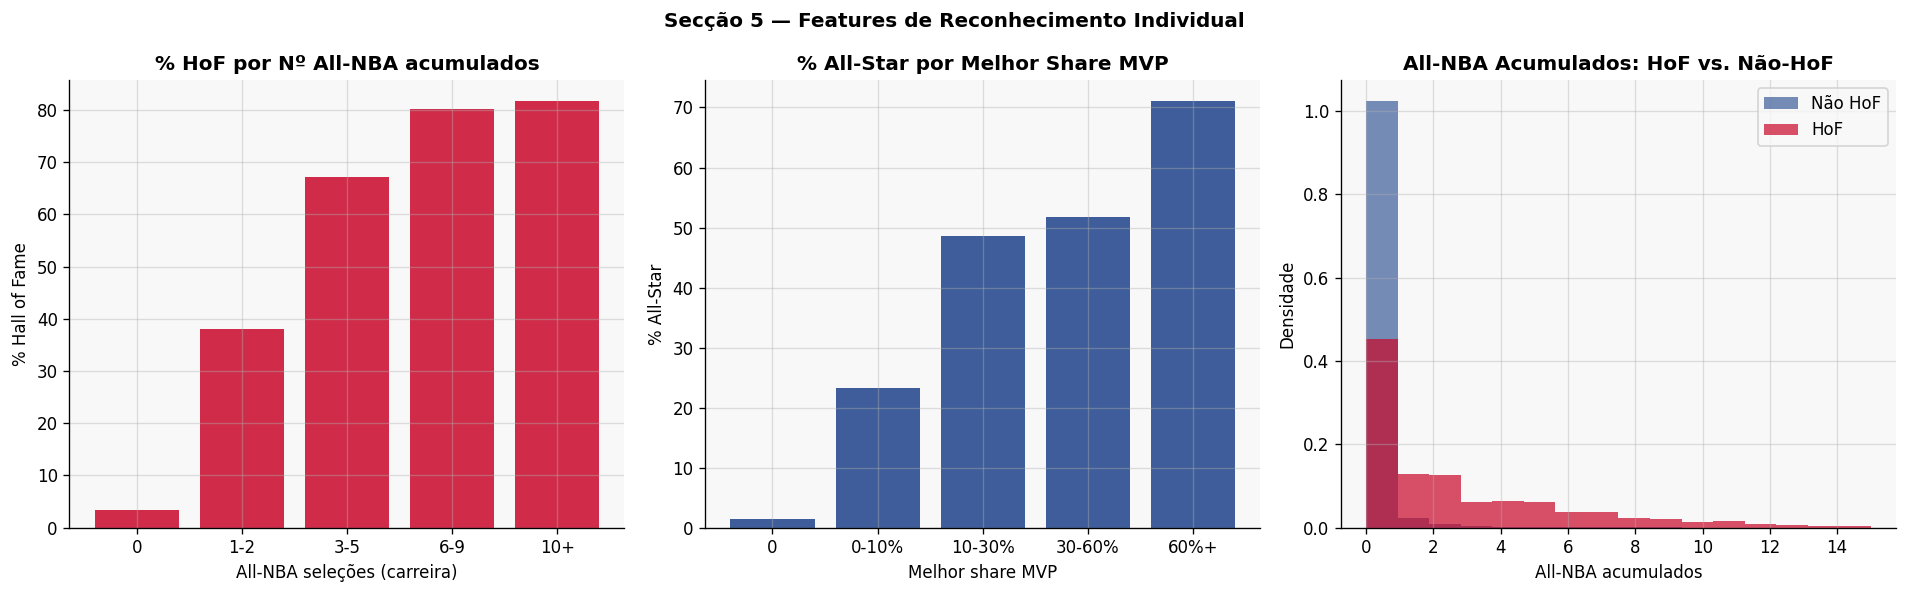

In [112]:
# Visualização das   features de reconhecimento
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# HoF rate por número de All-NBA acumulados
df_valid = df[df['career_allnba_count'].notna()].copy()
df_valid['allnba_bin'] = pd.cut(df_valid['career_allnba_count'], bins=[-1, 0, 2, 5, 9, 20], labels=['0', '1-2', '3-5', '6-9', '10+'])
hof_by_allnba = df_valid.groupby('allnba_bin', observed=True)['hof'].mean() * 100
axes[0].bar(hof_by_allnba.index.astype(str), hof_by_allnba.values, color=PALETTE[0], alpha=0.85)
axes[0].set_title('% HoF por Nº All-NBA acumulados', fontweight='bold')
axes[0].set_xlabel('All-NBA seleções (carreira)')
axes[0].set_ylabel('% Hall of Fame')

# AllStar rate por best MVP share
df['mvp_share_bin'] = pd.cut(df['best_mvp_share'],  bins=[-0.01, 0, 0.1, 0.3, 0.6, 1.0], labels=['0', '0-10%', '10-30%', '30-60%', '60%+'])
allstar_by_mvp = df.groupby('mvp_share_bin', observed=True)['is_allstar'].mean() * 100
axes[1].bar(allstar_by_mvp.index.astype(str), allstar_by_mvp.values, color=PALETTE[1], alpha=0.85)
axes[1].set_title('% All-Star por Melhor Share MVP', fontweight='bold')
axes[1].set_xlabel('Melhor share MVP')
axes[1].set_ylabel('% All-Star')

# Distribuição de career_allnba_count para HoF vs. não-HoF
hof_allnba  = df[df['hof'] == True]['career_allnba_count'].clip(0, 15)
nhof_allnba = df[df['hof'] == False]['career_allnba_count'].clip(0, 15)
axes[2].hist(nhof_allnba, bins=16, alpha=0.6, color=PALETTE[1], label='Não HoF', density=True)
axes[2].hist(hof_allnba,  bins=16, alpha=0.7, color=PALETTE[0], label='HoF',     density=True)
axes[2].set_title('All-NBA Acumulados: HoF vs. Não-HoF', fontweight='bold')
axes[2].set_xlabel('All-NBA acumulados')
axes[2].set_ylabel('Densidade')
axes[2].legend()

plt.suptitle('Secção 5 — Features de Reconhecimento Individual', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec5_reconhecimento.png', bbox_inches='tight')
plt.show()

---
## Features de Draft

A posição no draft é um proxy da expectativa gerada em torno de um jogador. Jogadores escolhidos muito cedo têm mais pressão e oportunidades, mas também representam o talento percebido pelos scouts no momento do draft.

| Feature | Descrição |
|---|---|
| `draft_pick` | Posição global no draft (1 = 1ª escolha) |
| `draft_round` | Ronda do draft (1 ou 2) |
| `is_lottery_pick` | Se foi escolhido nas primeiras 14 posições |
| `is_first_round` | Se foi escolhido na 1ª ronda |
| `is_undrafted` | Se não foi draftado |
| `draft_pick_normalized` | Pick normalizado (1 = melhor, 0 = pior/undrafted) |

In [113]:
# Preparar dados de Draft
draft_clean = draft_df[draft_df['lg'] == 'NBA'][['player_id', 'overall_pick', 'round']].copy()
draft_clean = draft_clean.rename(columns={'overall_pick': 'draft_pick', 'round': 'draft_round'})

# Guardar apenas a primeira entrada (alguns jogadores foram draftados mais de uma vez)
draft_clean = draft_clean.drop_duplicates(subset='player_id', keep='first')

df = df.merge(draft_clean, on='player_id', how='left')

# Derivar features de draft
df['is_undrafted'] = df['draft_pick'].isna().astype(int)
df['is_lottery_pick'] = (df['draft_pick'] <= 14).astype(int)
df['is_first_round'] = (df['draft_round'] == 1).astype(int)
df['is_second_round'] = (df['draft_round'] == 2).astype(int)

# 
max_pick = 60.0  # draft moderno tem 60 picks
df['draft_pick_normalized'] = np.where(df['draft_pick'].notna(),(1 - (df['draft_pick'] - 1) / (max_pick - 1)).clip(0, 1).round(3),0.0)  # undrafted = 0)

# Preencher draft_pick com valor para undrafted
df['draft_pick']  = df['draft_pick'].fillna(99)   # 99 = undrafted
df['draft_round'] = df['draft_round'].fillna(0)   # 0  = undrafted

FEATS_SEC6 = ['draft_pick', 'draft_round', 'is_undrafted', 'is_lottery_pick', 'is_first_round', 'is_second_round', 'draft_pick_normalized']

print("✓ Features de draft criadas:")
print(f"  Jogadores com dados de draft: {(df['draft_pick'] < 99).sum():,}")
print(f"  Undrafted: {df['is_undrafted'].sum():,}")
print(f"  Lottery picks (top 14): {df['is_lottery_pick'].sum():,}")
print(f"  1ª Ronda: {df['is_first_round'].sum():,}")
print(f"  2ª Ronda: {df['is_second_round'].sum():,}")

✓ Features de draft criadas:
  Jogadores com dados de draft: 25,262
  Undrafted: 5,261
  Lottery picks (top 14): 10,532
  1ª Ronda: 15,909
  2ª Ronda: 7,065


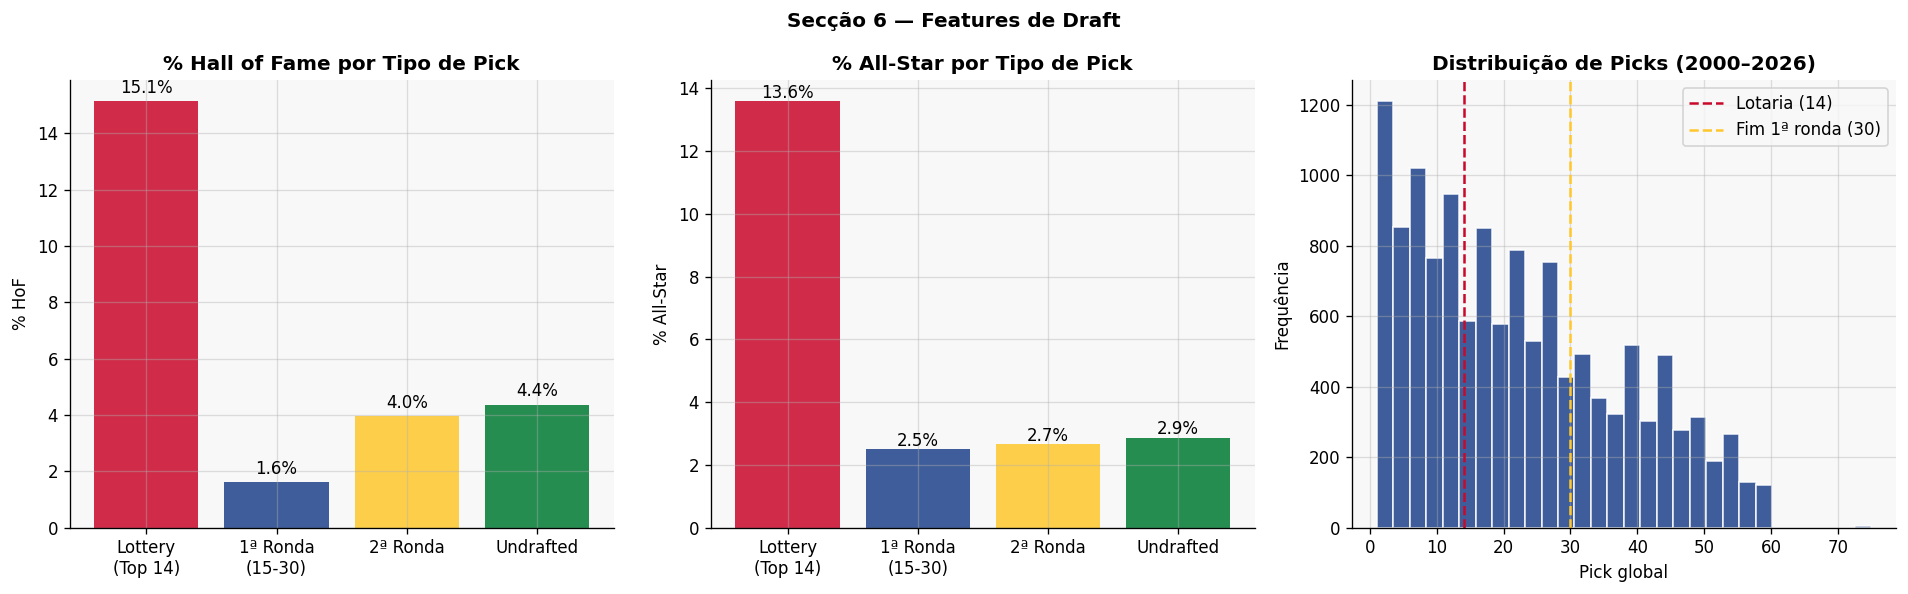

In [114]:
# Visualização das features de draft
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# % HoF por tipo de pick
pick_types = ['Lottery\n(Top 14)', '1ª Ronda\n(15-30)', '2ª Ronda', 'Undrafted']
hof_rates  = [
    df[df['is_lottery_pick'] == 1]['hof'].mean() * 100,
    df[(df['is_first_round'] == 1) & (df['is_lottery_pick'] == 0)]['hof'].mean() * 100,
    df[df['is_second_round'] == 1]['hof'].mean() * 100,
    df[df['is_undrafted'] == 1]['hof'].mean() * 100,
]
axes[0].bar(pick_types, hof_rates, color=PALETTE[:4], alpha=0.85)
for i, (x, v) in enumerate(zip(pick_types, hof_rates)):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)
axes[0].set_title('% Hall of Fame por Tipo de Pick', fontweight='bold')
axes[0].set_ylabel('% HoF')

# % All-Star por tipo de pick
allstar_rates = [
    df[df['is_lottery_pick'] == 1]['is_allstar'].mean() * 100,
    df[(df['is_first_round'] == 1) & (df['is_lottery_pick'] == 0)]['is_allstar'].mean() * 100,
    df[df['is_second_round'] == 1]['is_allstar'].mean() * 100,
    df[df['is_undrafted'] == 1]['is_allstar'].mean() * 100,
]
axes[1].bar(pick_types, allstar_rates, color=PALETTE[:4], alpha=0.85)
for i, v in enumerate(allstar_rates):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=10)
axes[1].set_title('% All-Star por Tipo de Pick', fontweight='bold')
axes[1].set_ylabel('% All-Star')

# Distribuição de picks nos últimos 20 anos
recent = df[(df['season'] >= 2000) & (df['draft_pick'] < 99)]
axes[2].hist(recent['draft_pick'], bins=30, color=PALETTE[1], alpha=0.85, edgecolor='white')
axes[2].axvline(x=14, color=PALETTE[0], linestyle='--', linewidth=1.5, label='Lotaria (14)')
axes[2].axvline(x=30, color=PALETTE[2], linestyle='--', linewidth=1.5, label='Fim 1ª ronda (30)')
axes[2].set_title('Distribuição de Picks (2000–2026)', fontweight='bold')
axes[2].set_xlabel('Pick global')
axes[2].set_ylabel('Frequência')
axes[2].legend()

plt.suptitle('Secção 6 — Features de Draft', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec6_draft.png', bbox_inches='tight')
plt.show()

---
## Análise das Novas Features

Antes de guardar o dataset, analisamos a qualidade e a relevância das novas features:
1. Resumo global — quantas features foram criadas e a sua completude
2. Correlações com os targets — quais as features mais preditivas
3. Matriz de correlação entre as novas features — detetar uma relação linear forte

In [115]:
# Resumo de todas as novas features
TODAS_NOVAS_FEATURES = (
    FEATS_SEC1 + [c for c in FEATS_SEC2 if c != 'era'] +
    [c for c in FEATS_SEC3 if c != 'player_tier'] +
    [c for c in FEATS_SEC4 if c not in ['height_category', 'career_bin']] +
    FEATS_SEC5 + FEATS_SEC6
)
# Remover eventuais duplicados
TODAS_NOVAS_FEATURES = list(dict.fromkeys(TODAS_NOVAS_FEATURES))

TODAS_NOVAS_FEATURES = [f for f in TODAS_NOVAS_FEATURES if f in df.columns]

print(f"Total de novas features criadas: {len(TODAS_NOVAS_FEATURES)}")
print(f"Total de colunas no dataset: {df.shape[1]}")
print(f"Colunas originais: {len(COLUNAS_ORIGINAIS)}")
print(f"Novas colunas adicionadas: {df.shape[1] - len(COLUNAS_ORIGINAIS)}")
print()

# Tabela de resumo das novas features
resumo_rows = []
for f in TODAS_NOVAS_FEATURES:
    serie = df[f]
    if pd.api.types.is_numeric_dtype(serie):
        resumo_rows.append({
            'Feature': f,
            'Tipo': str(serie.dtype),
            'Nulos (%)': round(serie.isnull().sum() / len(serie) * 100, 1),
            'Média': round(serie.mean(), 3),
            'Std': round(serie.std(), 3),
            'Min': round(serie.min(), 3),
            'Max': round(serie.max(), 3),
        })
    else:
        resumo_rows.append({
            'Feature': f,
            'Tipo': str(serie.dtype),
            'Nulos (%)': round(serie.isnull().sum() / len(serie) * 100, 1),
            'Média': '-',
            'Std': '-',
            'Min': '-',
            'Max': '-',
        })

resumo_df = pd.DataFrame(resumo_rows)
resumo_df.index = range(1, len(resumo_df) + 1)

def color_nulls(val):
    if isinstance(val, (int, float)):
        if val < 5:   
            return 'background-color: #d4edda'
        elif val < 20: 
            return 'background-color: #fff3cd'
        else:          
            return 'background-color: #f8d7da'
    return ''

resumo_df.style.applymap(color_nulls, subset=['Nulos (%)']).set_caption('Resumo das Novas Features')

Total de novas features criadas: 51
Total de colunas no dataset: 112
Colunas originais: 56
Novas colunas adicionadas: 56



,Feature,Tipo,Nulos (%),Média,Std,Min,Max
1,ast_tov_ratio,float64,0.000000,1.569000,1.116000,0.000000,20.000000
2,scoring_efficiency,float64,0.000000,3.694000,2.630000,0.000000,21.172000
3,pure_scorer_index,float64,1.600000,0.386000,0.138000,0.000000,3.000000
4,two_way_score,float64,0.000000,2.493000,2.942000,-2.900000,25.400000
5,box_score_composite,float64,0.000000,12.189000,8.072000,-3.600000,70.070000
6,stl_blk_per_game,float64,0.000000,0.934000,0.763000,0.000000,6.800000
7,orb_share,float64,1.800000,0.247000,0.149000,0.000000,1.000000
8,pts_era_zscore,float64,14.600000,-0.000000,0.999000,-1.654000,5.154000
9,per_era_zscore,float64,16.000000,0.000000,0.999000,-3.863000,4.658000
10,ws_era_zscore,float64,14.600000,0.000000,0.999000,-1.875000,6.161000


In [116]:
# Correlação das novas features com os targets
TARGETS = ['is_allstar', 'hof', 'team_playoffs']
feats_numericas = [f for f in TODAS_NOVAS_FEATURES if pd.api.types.is_numeric_dtype(df[f])]

# Converter targets para int
for t in TARGETS:
    df[t] = pd.to_numeric(df[t], errors='coerce').fillna(0).astype(int)

corr_targets = pd.DataFrame(index=feats_numericas)
for target in TARGETS:
    corr_targets[target] = [
        df[[f, target]].dropna().corr().iloc[0, 1]
        for f in feats_numericas
    ]
corr_targets = corr_targets.round(3)

# Top 10 mais correlacionadas com cada target
print("=" * 60)
for target in TARGETS:
    top = corr_targets[target].abs().sort_values(ascending=False).head(10)
    print(f"\nTop 10 correlações com '{target}':")
    for feat, corr_val in zip(top.index, corr_targets.loc[top.index, target]):
        print(f"  {feat:<35} {corr_val:+.3f}")


Top 10 correlações com 'is_allstar':
  is_allstar                          +1.000
  is_allnba_this_season               +0.636
  two_way_score                       +0.571
  ws_era_zscore                       +0.555
  box_score_composite                 +0.549
  pts_era_zscore                      +0.542
  pts_vs_era_avg                      +0.532
  scoring_efficiency                  +0.523
  is_top10_scorer                     +0.519
  is_top10_ws                         +0.502

Top 10 correlações com 'hof':
  career_allstar_count                +0.557
  ever_allnba_1st                     +0.553
  career_allnba_count                 +0.495
  best_mvp_share                      +0.491
  career_peak_ws                      +0.483
  is_allstar                          +0.480
  two_way_score                       +0.430
  is_allnba_this_season               +0.414
  box_score_composite                 +0.406
  ws_era_zscore                       +0.386

Top 10 correlações com 'team_p

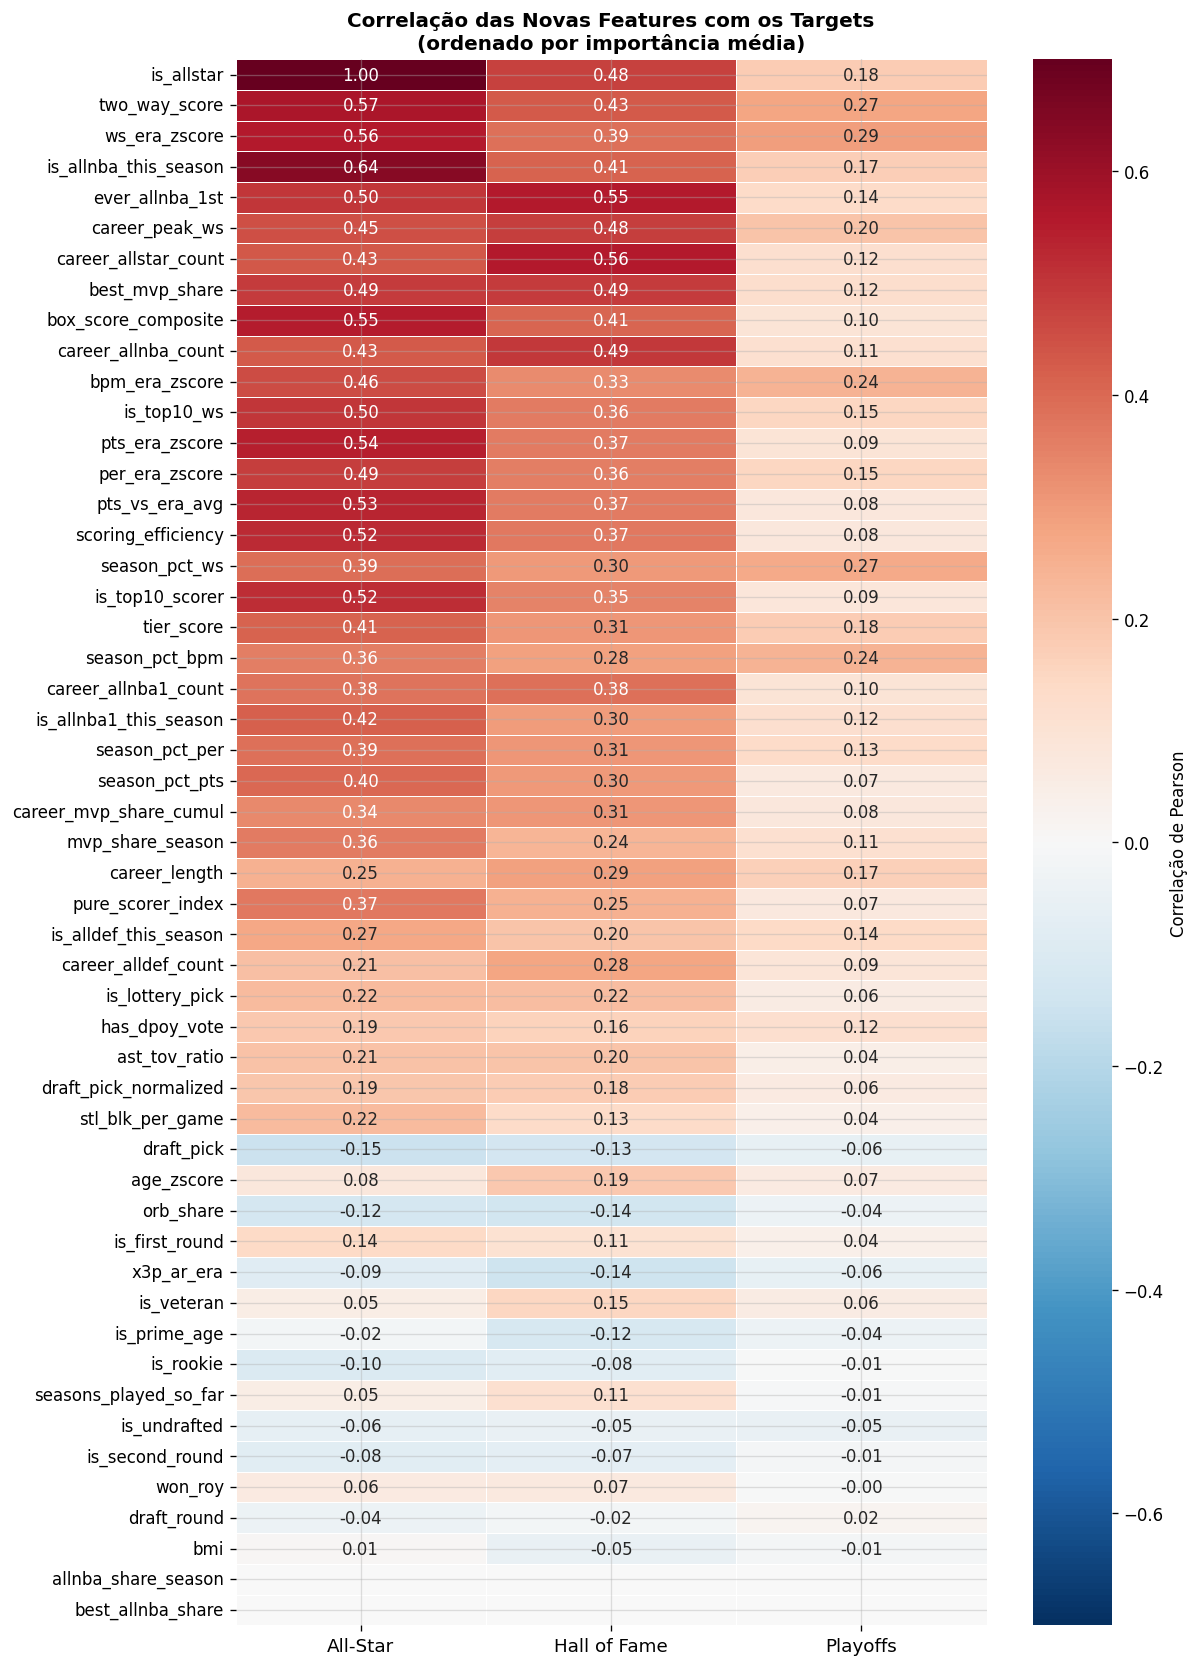

In [117]:
# Heatmap de correlação com targets
fig, axes = plt.subplots(1, 1, figsize=(10, 14))

# Ordenar por correlação absoluta média
corr_targets['abs_mean'] = corr_targets[TARGETS].abs().mean(axis=1)
corr_plot = corr_targets.sort_values('abs_mean', ascending=False).drop('abs_mean', axis=1)

sns.heatmap(
    corr_plot,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-0.7, vmax=0.7,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Correlação de Pearson'},
    ax=axes
)
axes.set_title('Correlação das Novas Features com os Targets\n(ordenado por importância média)', fontweight='bold', fontsize=12)
axes.set_xticklabels(['All-Star', 'Hall of Fame', 'Playoffs'], fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec7_correlacoes_targets.png', bbox_inches='tight')
plt.show()

In [118]:
# Relação linear forte entre as novas features
# Identificar pares de features altamente correlacionadas (|r| > 0.85)

corr_matrix = df[feats_numericas].corr().round(3)

# Detetar pares com correlação alta
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        c = corr_matrix.iloc[i, j]
        if abs(c) >= 0.85:
            high_corr_pairs.append({
                'Feature A': corr_matrix.columns[i],
                'Feature B': corr_matrix.columns[j],
                'Correlação': round(c, 3)
            })

hc_df = pd.DataFrame(high_corr_pairs).sort_values('Correlação', key=abs, ascending=False)
print(f"Pares de features com |correlação| >= 0.85:")
if len(hc_df) == 0:
    print("Nenhum par com multicolinearidade crítica encontrado.")
else:
    print(hc_df.to_string(index=False))
    print("\nNota: Os modelos de árvore (Random Forest, XGBoost) são robustos à multicolinearidade.")
    print("Para regressão logística, considerar remover uma das features de cada par.")

Pares de features com |correlação| >= 0.85:
           Feature A              Feature B  Correlação
      pts_era_zscore         pts_vs_era_avg       0.995
  scoring_efficiency         pts_vs_era_avg       0.989
  scoring_efficiency         pts_era_zscore       0.984
       two_way_score          ws_era_zscore       0.984
  scoring_efficiency    box_score_composite       0.970
 box_score_composite         pts_vs_era_avg       0.964
 box_score_composite         pts_era_zscore       0.957
      per_era_zscore         season_pct_per       0.956
      bpm_era_zscore         season_pct_bpm       0.953
       season_pct_ws             tier_score       0.945
      pts_era_zscore         season_pct_pts       0.944
      pts_vs_era_avg         season_pct_pts       0.938
          draft_pick  draft_pick_normalized      -0.937
  scoring_efficiency         season_pct_pts       0.935
 box_score_composite         season_pct_pts       0.917
      season_pct_pts             tier_score       0.911
    

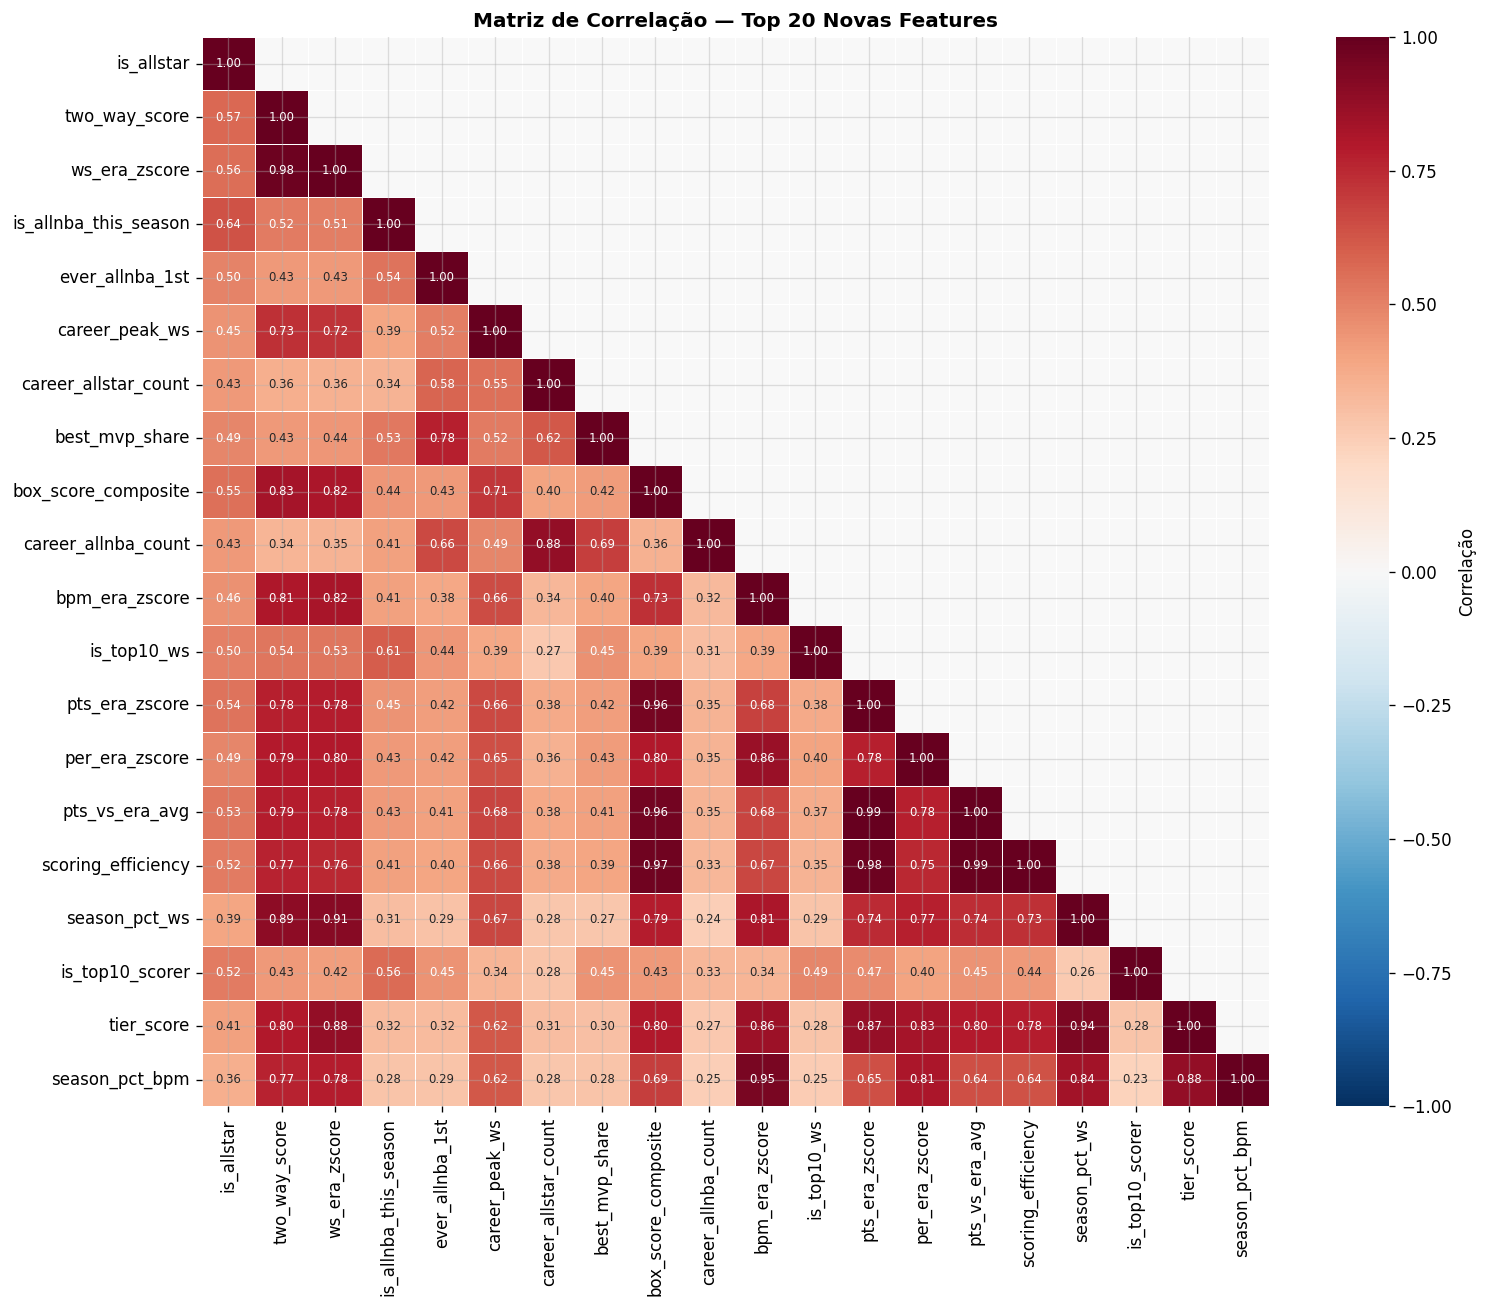

In [119]:
# Matriz de correlação entre as novas features
top_feats = corr_targets.drop('abs_mean', errors='ignore').abs().mean(axis=1).nlargest(20).index.tolist()
top_feats = [f for f in top_feats if f in feats_numericas]

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_matrix.loc[top_feats, top_feats], dtype=bool), k=1)
sns.heatmap(
    corr_matrix.loc[top_feats, top_feats],
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    mask=mask,
    vmin=-1, vmax=1,
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Correlação'},
    ax=ax, annot_kws={'size': 7}
)
ax.set_title('Matriz de Correlação — Top 20 Novas Features', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}03_sec7_matriz_correlacao.png', bbox_inches='tight')
plt.show()

---
## Guardar Dataset Enriquecido

Guardamos o dataset final com todas as novas features para uso nos notebooks de Machine Learning da Parte II.

In [120]:
# Limpeza final

# Remover colunas auxiliares temporárias usadas só no cálculo
cols_to_drop = ['career_bin', 'mvp_share_bin', 'mvp_winner', 'tier_score']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df_final = df.drop(columns=cols_to_drop)

# Colunas categóricas novas: codificar para versão label (manter original também)
df_final['era_code'] = pd.Categorical(df_final['era']).codes
df_final['height_category_code'] = pd.Categorical(df_final['height_category']).codes
df_final['player_tier_code'] = pd.Categorical(df_final['player_tier'], categories=['Fringe','Bench','Rotation','Starter','Star'], ordered=True).codes

print(f"Dataset final: {df_final.shape[0]:,} registos × {df_final.shape[1]} colunas")
print(f"Colunas originais: {len(COLUNAS_ORIGINAIS)}")
print(f"Novas features: {df_final.shape[1] - len(COLUNAS_ORIGINAIS)}")

Dataset final: 30,987 registos × 111 colunas
Colunas originais: 56
Novas features: 55


In [121]:
# Validação final dos targets
print("Distribuição final dos targets:")
print()
for t in TARGETS:
    vals = df_final[t].value_counts(dropna=False)
    total = len(df_final)
    print(f"{t}:")
    for k, v in vals.items():
        print(f"{str(k):<10} - {v:,} ({v/total*100:.1f}%)")
    print()

# Verificar nulos nos targets
print("Nulos nos targets:")
for t in TARGETS:
    print(f"{t}: {df_final[t].isnull().sum()} nulos")

Distribuição final dos targets:

is_allstar:
0          - 29,068 (93.8%)
1          - 1,919 (6.2%)

hof:
0          - 28,737 (92.7%)
1          - 2,250 (7.3%)

team_playoffs:
0          - 18,399 (59.4%)
1          - 12,588 (40.6%)

Nulos nos targets:
is_allstar: 0 nulos
hof: 0 nulos
team_playoffs: 0 nulos


In [122]:
# Exportar dataset enriquecido
output_path = f'{OUTPUT_DIR}dataset_nba_enriched.csv'
# ✅ Garantir que os targets ficam como int no ficheiro final
for t in ['is_allstar', 'hof', 'team_playoffs']:
    if t in df_final.columns:
        df_final[t] = df_final[t].fillna(0).astype(int)
df_final.to_csv(output_path, index=False)

file_size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"Dataset enriquecido guardado em: {output_path}")
print(f"Dimensão: {df_final.shape[0]:,} linhas × {df_final.shape[1]} colunas")
print(f"Tamanho: {file_size_mb:.1f} MB")
print()
print("Colunas no dataset final:")
for i, col in enumerate(df_final.columns, 1):
    marker = '(NOVA)' if col not in COLUNAS_ORIGINAIS else ''
    print(f"{i:3d}. {col}{marker}")

Dataset enriquecido guardado em: ./outputs/dataset_nba_enriched.csv
Dimensão: 30,987 linhas × 111 colunas
Tamanho: 14.1 MB

Colunas no dataset final:
  1. season
  2. lg
  3. player
  4. player_id
  5. age
  6. team
  7. pos
  8. g
  9. gs
 10. mp_per_game
 11. fg_per_game
 12. fga_per_game
 13. fg_percent
 14. x3p_per_game
 15. x3pa_per_game
 16. x3p_percent
 17. x2p_per_game
 18. x2pa_per_game
 19. x2p_percent
 20. e_fg_percent
 21. ft_per_game
 22. fta_per_game
 23. ft_percent
 24. orb_per_game
 25. drb_per_game
 26. trb_per_game
 27. ast_per_game
 28. stl_per_game
 29. blk_per_game
 30. tov_per_game
 31. pf_per_game
 32. pts_per_game
 33. per
 34. ts_percent
 35. usg_percent
 36. ows
 37. dws
 38. ws
 39. ws_48
 40. obpm
 41. dbpm
 42. bpm
 43. vorp
 44. trp_dbl
 45. birth_date
 46. hof
 47. from
 48. to
 49. colleges
 50. experience
 51. is_allstar
 52. team_playoffs
 53. height_cm
 54. weight_kg
 55. decade
 56. is_nba
 57. ast_tov_ratio(NOVA)
 58. scoring_efficiency(NOVA)
 59. p

In [123]:
seccoes = [
    ('Secção 1 — Eficiência Ofensiva',FEATS_SEC1),
    ('Secção 2 — Era Temporal', [c for c in FEATS_SEC2 if c != 'era']),
    ('Secção 3 — Tier/Nível', [c for c in FEATS_SEC3 if c != 'player_tier']),
    ('Secção 4 — Físico/Demográfico', [c for c in FEATS_SEC4 if c not in ['height_category', 'career_bin']]),
    ('Secção 5 — Reconhecimento', FEATS_SEC5),
    ('Secção 6 — Draft', FEATS_SEC6),
]

total = 0
for nome, feats in seccoes:
    feats_validas = [f for f in feats if f in df_final.columns]
    total += len(feats_validas)
    print(f"{nome} - {len(feats_validas)} features")

# Adicionar as codificadas
print(f"{'Codificações categóricas'} - 3 features")
total += 3

print()
print(f"Total de novas features criadas: {total}")

Secção 1 — Eficiência Ofensiva - 7 features
Secção 2 — Era Temporal - 6 features
Secção 3 — Tier/Nível - 8 features
Secção 4 — Físico/Demográfico - 7 features
Secção 5 — Reconhecimento - 15 features
Secção 6 — Draft - 7 features
Codificações categóricas - 3 features

Total de novas features criadas: 53
